*Aim* : To compare the raw performance of selected drivers for the 2023 Brazil GP Qualifying session with the help of their telemetry(speed, brakes, throttle) and predict strategy of the best one.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.collections import LineCollection
from mpl_toolkits.mplot3d.art3d import Line3DCollection

import argparse
import os
parser = argparse.ArgumentParser()
parser.add_argument('--cache_dir', type=str, default='./cache')
args = parser.parse_known_args()[0]
if not os.path.exists(args.cache_dir):
    os.makedirs(args.cache_dir)
import fastf1
fastf1.Cache.enable_cache(args.cache_dir)

import fastf1.plotting
# Enable Matplotlib patches for plotting timedelta values and load
# FastF1's dark color scheme
fastf1.plotting.setup_mpl(mpl_timedelta_support=True, color_scheme='fastf1')
from fastf1 import utils

### Load the data

Load the data for the Brazil qualifying session. Select 3 drivers for telemetry analysis and get their fastest laps (ie their best laps).

In [30]:
session = fastf1.get_session(2023,'Brazil','Q')
session.load()

#select drivers
driver1 = 'VER'
driver2 = 'HAM'
driver3 = 'ALO'

qual1=session.laps.pick_drivers(driver1).pick_fastest()
qual2=session.laps.pick_drivers(driver2).pick_fastest()
qual3=session.laps.pick_drivers(driver3).pick_fastest()

core           INFO 	Loading data for São Paulo Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '16', '18', '14', '44', '63', '4', '55', '11', '81', '27', '31', '10', '20', '23', '22', '3', '77', '2', '24']


In [31]:
telemetry_1 = qual1.get_telemetry()
telemetry_2 = qual2.get_telemetry()
telemetry_3 = qual3.get_telemetry()
#Used get_telemetry instead of get_car_data because of more detailed data
print(telemetry_1.columns)

Index(['Date', 'SessionTime', 'DriverAhead', 'DistanceToDriverAhead', 'Time',
       'RPM', 'Speed', 'nGear', 'Throttle', 'Brake', 'DRS', 'Source',
       'Distance', 'RelativeDistance', 'Status', 'X', 'Y', 'Z'],
      dtype='object')


### Visualization

We have the telemetry data for 3 drivers- Verstappen, Hamilton and Alonso. We will look at their speed traces for the session.

In [46]:
time_diff1 = qual1['LapTime']-qual2['LapTime']
time_diff2 = qual1['LapTime']-qual3['LapTime']
time_diff1=time_diff1.total_seconds()
time_diff2=time_diff2.total_seconds()
#if negative, this means the subrahend driver was faster
print(time_diff1,time_diff2)
print(f'{driver1} was {np.abs(time_diff1):.3f} seconds faster than {driver2}')
print(f'{driver1} was {np.abs(time_diff2):.3f} seconds faster than {driver3}')

-0.10399999999999998 -0.07499999999999996
VER was 0.104 seconds faster than HAM
VER was 0.075 seconds faster than ALO


Verstappen was faster than Alonso( by 0.075s) and Hamilton( by 0.104s), now we have to see a detailed analysis how he managed to be quicker.

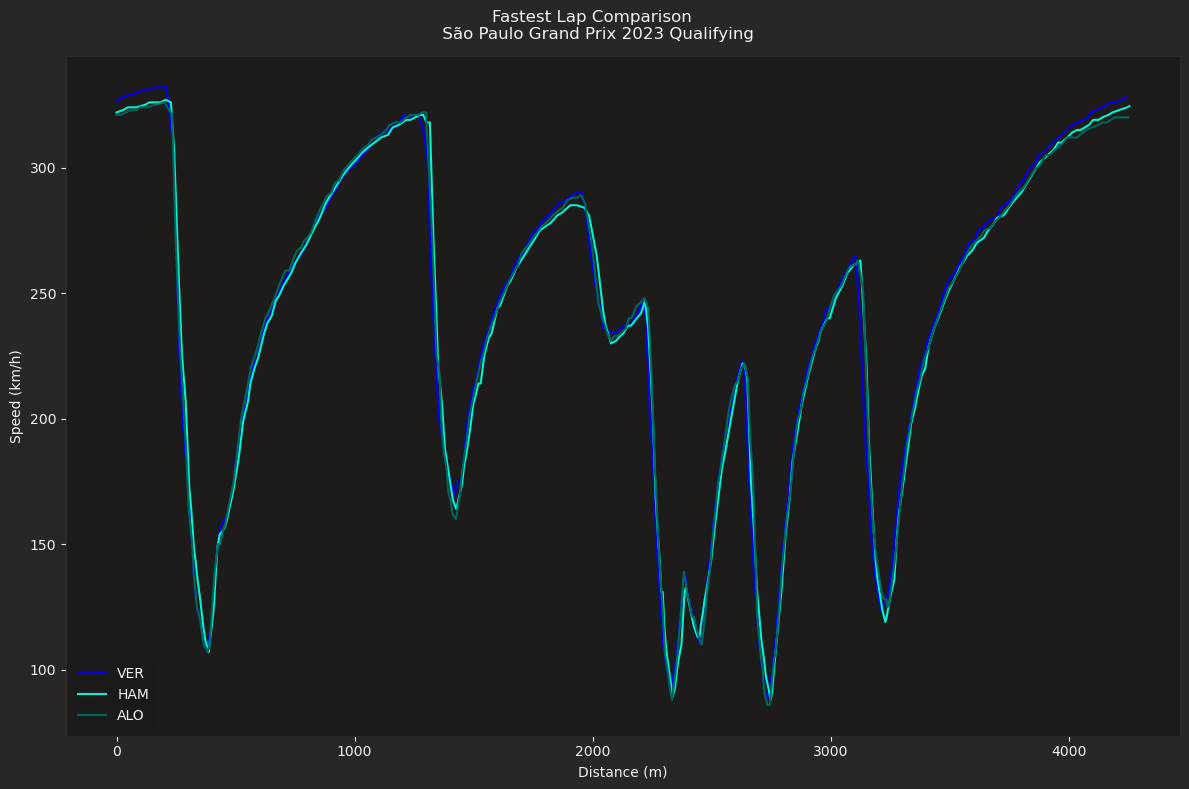

In [32]:
team_colour1 = fastf1.plotting.get_team_color(qual1['Team'], session=session)
team_colour2 = fastf1.plotting.get_team_color(qual2['Team'], session=session)
team_colour3 = fastf1.plotting.get_team_color(qual3['Team'], session=session)

fig,ax = plt.subplots(figsize=(12,8))
ax.plot(telemetry_1['Distance'],telemetry_1['Speed'],color=team_colour1,label=driver1)
ax.plot(telemetry_2['Distance'],telemetry_2['Speed'],color=team_colour2,label=driver2)
ax.plot(telemetry_3['Distance'],telemetry_3['Speed'],color=team_colour3,label=driver3)

ax.set_xlabel('Distance (m)');ax.set_ylabel('Speed (km/h)');ax.legend()
plt.suptitle(f"Fastest Lap Comparison \n "
             f"{session.event['EventName']} {session.event.year} Qualifying")
plt.tight_layout()
plt.show()

Let's go for an on-track visualisation of the speed graphs for the drivers. The projection would be 3d, showing the elevation of the track alongside the track layout with the speed trace.

In [33]:
#from telemetry data, import x y z coordinates
x1,x2,x3 = telemetry_1['X'],telemetry_2['X'],telemetry_3['X']
y1,y2,y3 = telemetry_1['Y'],telemetry_2['Y'],telemetry_3['Y']
z1,z2,z3 = telemetry_1['Z'],telemetry_2['Z'],telemetry_3['Z']

#colorbar
color1 = telemetry_1['Speed']
color2 = telemetry_2['Speed']
color3 = telemetry_3['Speed']

points1 = np.array([x1, y1, z1]).T.reshape(-1, 1, 3)
segments1 = np.concatenate([points1[:-1], points1[1:]], axis=1)

points2 = np.array([x2, y2, z2]).T.reshape(-1, 1, 3)
segments2 = np.concatenate([points2[:-1], points2[1:]], axis=1)

points3 = np.array([x3, y3, z3]).T.reshape(-1, 1, 3)
segments3 = np.concatenate([points3[:-1], points3[1:]], axis=1)

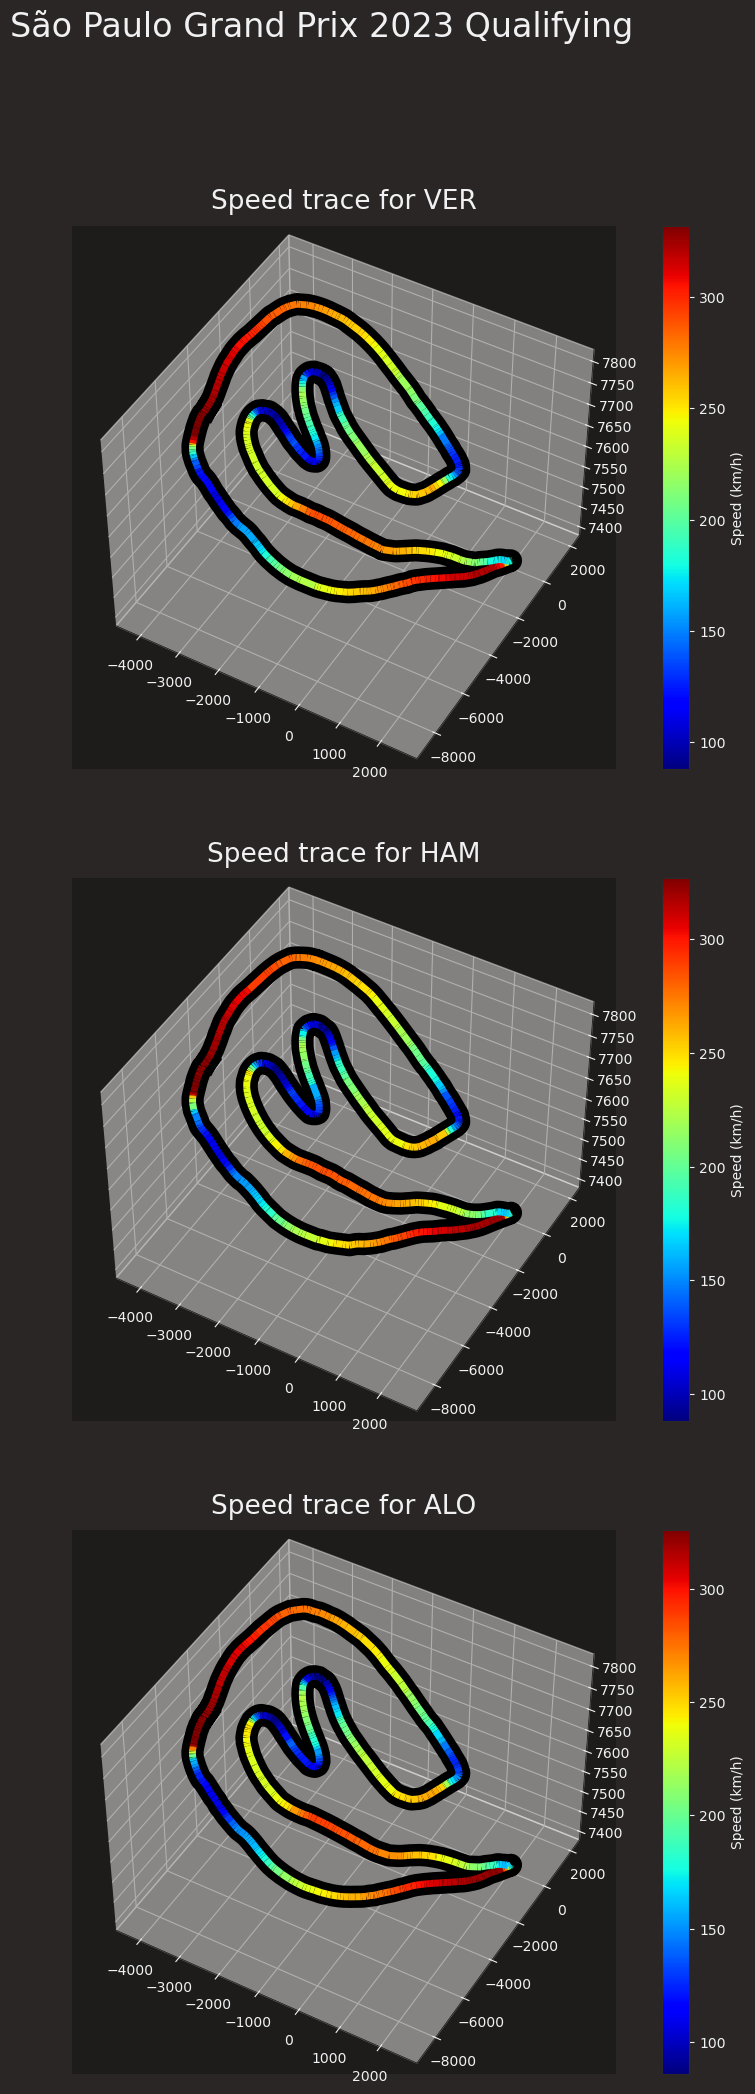

In [34]:
# setting up the visualisation 
fig = plt.figure(figsize=(12,24))
ax1=fig.add_subplot(3,1,1,projection='3d')
fig.suptitle(f"{session.event['EventName']} {session.event.year} Qualifying", size=24, y=0.97)

#Create background track line
ax1.plot(x1,y1,z1,color='black',linestyle='-',linewidth=16,zorder=1)

#continuous norm to map from data points to colors
norm1=plt.Normalize(color1.min(),color1.max())
lc1 = Line3DCollection(segments1,cmap='jet',norm=norm1,
                      linewidth=5,linestyle='-',zorder=2)
#Set colourmapping values
lc1.set_array(color1)
#Merge all line segments together
line1 = ax1.add_collection(lc1)

#Repeat for other two drivers

ax2=fig.add_subplot(3,1,2,projection='3d',sharex=ax1,sharey=ax1)
ax2.plot(x2,y2,z2,color='black',linestyle='-',linewidth=16,zorder=1)
norm2=plt.Normalize(color2.min(),color2.max())
lc2 = Line3DCollection(segments2,cmap='jet',norm=norm2,
                      linewidth=5,linestyle='-',zorder=2)
lc2.set_array(color2)
line2 = ax2.add_collection(lc2)

ax3=fig.add_subplot(3,1,3,projection='3d',sharex=ax1,sharey=ax1)
ax3.plot(x3,y3,z3,color='black',linestyle='-',linewidth=16,zorder=1)
norm3=plt.Normalize(color3.min(),color3.max())
lc3 = Line3DCollection(segments3,cmap='jet',norm=norm3,
                      linewidth=5,linestyle='-',zorder=2)
lc3.set_array(color3)
line3 = ax3.add_collection(lc3)

ax1.set_title(f'Speed trace for {qual1['Driver']}')
ax2.set_title(f'Speed trace for {qual2['Driver']}')
ax3.set_title(f'Speed trace for {qual3['Driver']}')

#change view angle
ax1.view_init(elev=45,azim=-60)
ax2.view_init(elev=45,azim=-60)
ax3.view_init(elev=45,azim=-60)
#creating colourbar legend
plt.colorbar(lc1, ax=ax1, label='Speed (km/h)')
plt.colorbar(lc2, ax=ax2, label='Speed (km/h)')
plt.colorbar(lc3, ax=ax3, label='Speed (km/h)')
plt.show()

### Deeper analysis

The speed trace curves generated in the visualization part does not give the full story of who was actually better since they look mostly similar. Thus it is prudent to calculate a time_delta( the gain/loss in time of one driver relative to the other). For this task, Verstappen is the chosen reference driver. 

#### Delta time

C:\Users\dell\anaconda3\Lib\site-packages\fastf1\utils.py:85: FutureWarning: `utils.delta_time` is considered deprecated and willbe modified or removed in a future release because it hasa tendency to give inaccurate results.
  warnings.warn("`utils.delta_time` is considered deprecated and will"
C:\Users\dell\anaconda3\Lib\site-packages\fastf1\utils.py:85: FutureWarning: `utils.delta_time` is considered deprecated and willbe modified or removed in a future release because it hasa tendency to give inaccurate results.
  warnings.warn("`utils.delta_time` is considered deprecated and will"


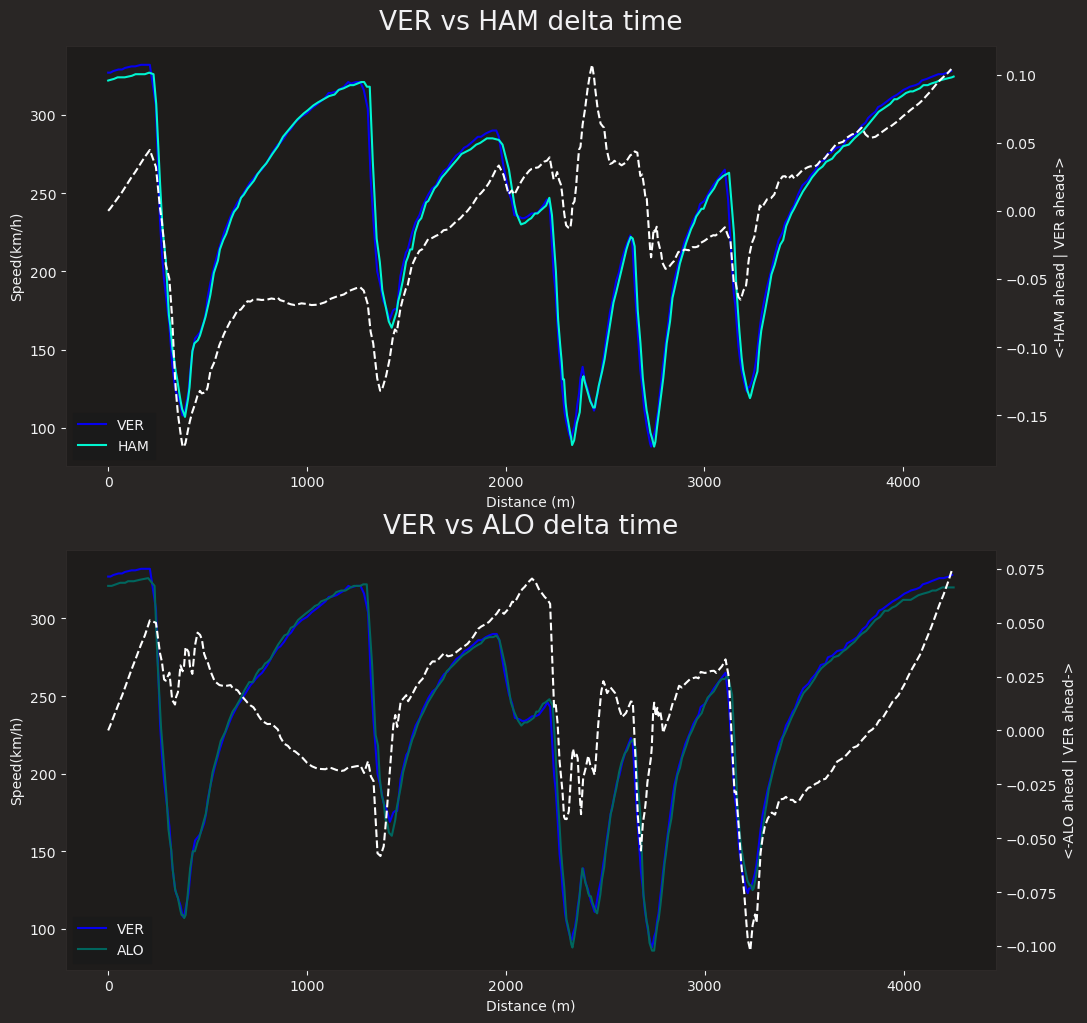

In [35]:
delta_time1, ref_tel1, compare_tel1 = utils.delta_time(qual1,qual2)
delta_time2, ref_tel2, compare_tel2 = utils.delta_time(qual1,qual3)

fig,ax = plt.subplots(2,1,figsize=(12,12))
ax[0].plot(ref_tel1['Distance'],ref_tel1['Speed'],
          color = team_colour1,label=f'{qual1['Driver']}')
ax[0].plot(compare_tel1['Distance'],compare_tel1['Speed'],
          color = team_colour2,label=f'{qual2['Driver']}')
#share same x axis with different y values
twin1 = ax[0].twinx()
twin1.plot(ref_tel1['Distance'],delta_time1,'--',color='white',label='delta time')
twin1.set_ylabel(f'<-{qual2['Driver']} ahead | {qual1['Driver']} ahead->')
twin1.set_title(f'{driver1} vs {driver2} delta time')
ax[0].set_xlabel('Distance (m)');ax[0].set_ylabel('Speed(km/h)');ax[0].legend()

ax[1].plot(ref_tel2['Distance'],ref_tel2['Speed'],
          color = team_colour1,label=f'{qual1['Driver']}')
ax[1].plot(compare_tel2['Distance'],compare_tel2['Speed'],
          color = team_colour3,label=f'{qual3['Driver']}')
#share same x axis with different y values
twin2 = ax[1].twinx()
twin2.plot(ref_tel2['Distance'],delta_time2,'--',color='white',label='delta time')
twin2.set_ylabel(f'<-{qual3['Driver']} ahead | {qual1['Driver']} ahead->')
twin2.set_title(f'{driver1} vs {driver3} delta time')
ax[1].set_xlabel('Distance (m)');ax[1].set_ylabel('Speed(km/h)');ax[1].legend()
plt.show()

For the Hamilton-Verstappen graph, it can be seen that Hamilton started out faster but Verstappen caught up at nearly 2000m( from the middle of the lap) and gradually increased his lead, with the occasional hiccup. However, Hamilton was noted to be faster at corners with low speed, while Verstappen reduced the deficit on straights. The Alonso- Verstappen graph is a little complicated, Alonso started poorly but slowly overtook Verstappen nearing the 1000 meter mark, before losing out completely at the midpoint. The second half had its ups and downs but at the final stretch, Verstappen became untouchable.

#### Looking at a specific corner

Zooming into the region between 1100 and 1800m, where the speed shows a massive change, to see how the selected drivers navigated the stretch

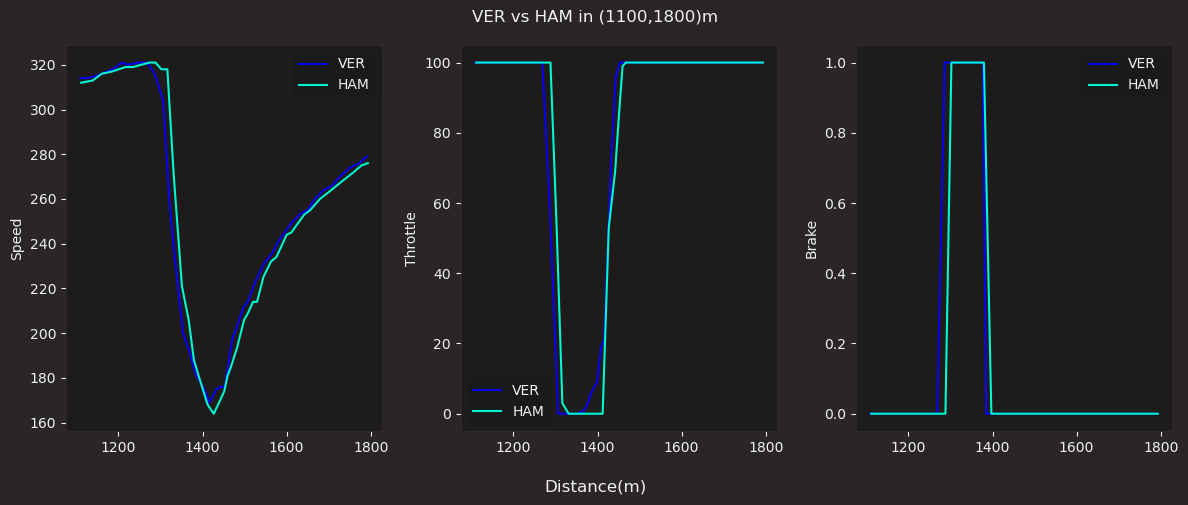

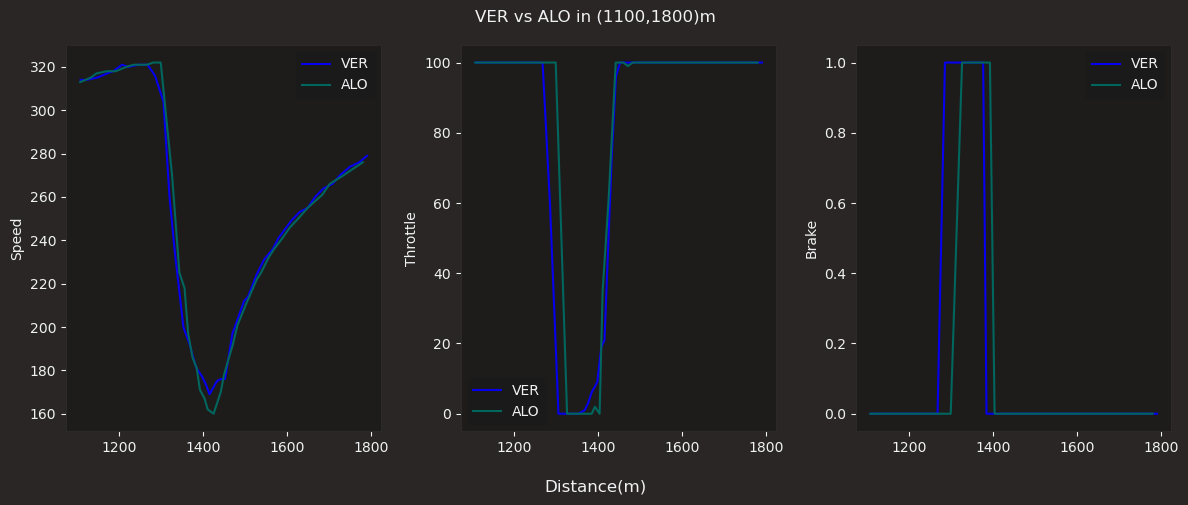

In [36]:
start,end = 1100,1800

fig,axes = plt.subplots(1,3,figsize=(12,5),sharex=True)

for tel, driver, color in [(ref_tel1,driver1,team_colour1),(compare_tel1,driver2,team_colour2)]:
    #filter out the stretch
    mask = (tel['Distance']>=start) & (tel['Distance']<=end)
    axes[0].plot(tel['Distance'][mask],tel['Speed'][mask],label=driver,color=color)
    axes[1].plot(tel['Distance'][mask],tel['Throttle'][mask],label=driver,color=color)
    axes[2].plot(tel['Distance'][mask],tel['Brake'][mask],label=driver,color=color)
axes[0].set_ylabel('Speed');axes[0].legend()
axes[1].set_ylabel('Throttle');axes[1].legend()
axes[2].set_ylabel('Brake');axes[2].legend()
fig.suptitle(f'{driver1} vs {driver2} in ({start},{end})m')
fig.supxlabel('Distance(m)')
plt.tight_layout()
plt.show()

fig1,axes1 = plt.subplots(1,3,figsize=(12,5),sharex=True)
for tel, driver, color in [(ref_tel2,driver1,team_colour1),(compare_tel2,driver3,team_colour3)]:
    #filter out the stretch
    mask = (tel['Distance']>=start) & (tel['Distance']<=end)
    axes1[0].plot(tel['Distance'][mask],tel['Speed'][mask],label=driver,color=color)
    axes1[1].plot(tel['Distance'][mask],tel['Throttle'][mask],label=driver,color=color)
    axes1[2].plot(tel['Distance'][mask],tel['Brake'][mask],label=driver,color=color)
axes1[0].set_ylabel('Speed');axes1[0].legend()
axes1[1].set_ylabel('Throttle');axes1[1].legend()
axes1[2].set_ylabel('Brake');axes1[2].legend()
fig1.suptitle(f'{driver1} vs {driver3} in ({start},{end})m')
fig1.supxlabel('Distance(m)')
plt.tight_layout()
plt.show()

*Hamilton-Verstappen comparison* - Verstappen entered the corner slower than Hamilton, also braking a bit earlier, but released his brakes a fraction of time faster than Hamilton and increased throttle way ahead, allowing him to pick up pace faster and thereby exit the corner ahead of his competitor.

*Alonso-Verstappen comparison* - Both approached the corner at the same speed. Verstappen braked way earlier, and exited the corner losing less pace than Alonso. The latter entered the corner at a much higher speed and applied his brakes way late, which meant he lost a lot of pace, giving Verstappen a huge advantage in terms of lap time.

### Conclusion

Looking at the calculated parametrics, Verstappen emerged to be the best among the three selected drivers in the Brazil 2023 Qualifying session. His strategy of braking earlier than others while approaching corners allowed him to exit corners with a much higher speed to enter on the straights, leading to better lap times.

Although, Hamilton appeared to reduce the time difference at corners, Verstappen dominated in straights, due to him exiting the corners at higher speed. Alonso, despite starting poorly, reduced the difference over the first quarter, however, in the corner between 1100 to 1600m, his speed was too high. He braked too late, and lost valuable time navigating the corner. 

Verstappen's strategy was to approach the corners at a lower speed, braking earlier and increasing throttle earlier than the rest of the pack which was an excellent strategy for Monaco's sharp corners. Hamilton and Alonso, despite being good drivers, played it too textbook style and thus had worse lap times.

*Future scope*
- Add an average of all parameters to the comparison, which would validate the conclusion drawn in this analysis.
- The 3 dimensional speed trace plot showing the elevation of the track could look better with better view angles or interactive plot.
- The speed trace plots could be animated, being comparable to a virtual replay of the session and allowing better visualisation.